# Notebook 3: Feature Engineering and EDA Synthesis

**Course:** Data Engineering - Unsupervised Learning Project  
**University:** Bar-Ilan University, Spring 2026  
**Dataset:** NYC PLUTO - 858,644 lots/buildings across New York City  

## Sections Covered
- [x] **Section 6** - Feature Engineering: new features, log transforms, categorical handling, standardisation  
- [x] **Section 7** - Unbalanced Data: borough and land-use distributions  
- [x] **Section 8** - Final Synthesis and Preprocessing Recommendations  

## Research Question
> *How can we build, from the physical, functional and geographical characteristics
> of the PLUTO dataset, an unsupervised segmentation of NYC buildings to identify
> homogeneous urban profiles and analyze their distribution across the five boroughs?*

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
df = pd.read_csv('data/raw/pluto_working_copy.csv', low_memory=False)
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

# The raw CSV uses a Narrow No-Break Space (U+202F) as a thousands separator
# (e.g. "2660" is stored as "2 660"). This is a French locale export format.
# Stripping unconditionally works across all pandas versions.
numeric_cols = ['yearbuilt', 'lotarea', 'bldgarea', 'numfloors',
                'lotfront', 'lotdepth', 'unitstotal', 'unitsres',
                'resarea', 'comarea', 'officearea', 'retailarea',
                'garagearea', 'strgearea', 'assesstot']
for col in numeric_cols:
    if col in df.columns:
        df[col] = (df[col].astype(str)
                          .str.replace(' ', '', regex=False)
                          .str.replace(r'[^\d.\-]', '', regex=True)
                          .replace('', np.nan))
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 104 is the real physical ceiling for NYC buildings (One World Trade Center).
# Values above 104 are parsing artifacts or source data entry errors.
if 'numfloors' in df.columns:
    df.loc[df['numfloors'] > 104, 'numfloors'] = np.nan

df.head(3)

Dataset loaded: 858,644 rows, 101 columns


,borough,Tax block,Tax lot,community board,census tract 2010,cb2010,schooldist,council district,postcode,firecomp,...,bctcb2020,geom,basempdate,dcasdate,edesigdate,landmkdate,masdate,polidate,rpaddate,zoningdate
0,QN,6173,23,411.0,1123,1002.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QN,6173,24,411.0,1123,1002.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,QN,6169,26,411.0,1123,2000.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Context Recap

The columns explored in Parts 1 and 2 fall into two roles. The numeric physical and functional
measurements are the clustering inputs; the administrative, categorical, and geographic columns are
kept for post-clustering interpretation only.

| Group | Features | Role in the model |
|---|---|---|
| Physical (6) | `lotarea`, `bldgarea`, `numfloors`, `lotfront`, `lotdepth`, `yearbuilt` | Clustering input. `yearbuilt` is winsorized and then converted into `building_age`; raw `yearbuilt` is not itself a clustering feature. |
| Functional (8) | `unitstotal`, `unitsres`, `resarea`, `comarea`, `officearea`, `retailarea`, `garagearea`, `strgearea` | Clustering input |
| Categorical and geographic (6) | `landuse`, `borough`, `postcode`, `community board`, `latitude`, `longitude` | Post-clustering interpretation only |

> **Methodological note:** `landuse` and `assesstot` (total assessed value) are deliberately excluded
> from the clustering input. Feeding an administrative land-use label into the clustering would
> reproduce the known land-use categories instead of discovering structure, and using assessed value
> would reduce the task to value-based segmentation. Both are kept for post-clustering interpretation
> only. `BBL` (borough-block-lot) is the unique tax-lot identifier.

The clustering uses 16 features: 13 source measurements (`lotarea`, `bldgarea`, `numfloors`,
`lotfront`, `lotdepth`, `unitstotal`, `unitsres`, `resarea`, `comarea`, `officearea`, `retailarea`,
`garagearea`, `strgearea`) and 3 engineered features (`building_age` derived from `yearbuilt`,
`building_density`, `residential_ratio`).

---
# Section 6: Feature Engineering

This section enriches the dataset with derived features that better capture the structural
and functional reality of NYC buildings. We also demonstrate the transformations needed
to make numerical features suitable for distance-based algorithms.

## 6.1: New Engineered Features

We create 4 new features, each with a clear analytical justification:

| Feature | Formula | Justification |
|---|---|---|
| `building_age` | `2026 - yearbuilt` | More interpretable than a raw year; directly measures temporal context and structural era |
| `building_density` | `bldgarea / lotarea` | Measures how intensively a lot is built upon - a key urban form indicator |
| `residential_ratio` | `unitsres / unitstotal` | Captures building character: 0 = purely commercial, 1 = purely residential |
| `value_per_sqft` | `assesstot / bldgarea` | **Post-clustering only** - normalised property value for cluster profiling |

**Edge cases handled:**
- `yearbuilt == 0` encodes an unknown year in the PLUTO data dictionary: `building_age = NaN`
- Division by zero in ratio features: `NaN` (using `np.where`) instead of `Inf`

In [3]:
# --- building_age -------------------------------------------------------
# yearbuilt == 0 means the construction year is unknown (PLUTO data dictionary)
df['building_age'] = 2026 - df['yearbuilt']
df.loc[df['yearbuilt'] == 0, 'building_age'] = np.nan

# --- building_density ---------------------------------------------------
# Ratio of total built surface to lot surface; undefined when lot has no area
df['building_density'] = np.where(
    df['lotarea'] > 0,
    df['bldgarea'] / df['lotarea'],
    np.nan
)

# --- residential_ratio --------------------------------------------------
# Share of residential units; undefined for buildings with zero total units
df['residential_ratio'] = np.where(
    df['unitstotal'] > 0,
    df['unitsres'] / df['unitstotal'],
    np.nan
)

# --- value_per_sqft (post-clustering interpretation only) ---------------
df['value_per_sqft'] = np.where(
    df['bldgarea'] > 0,
    df['assesstot'] / df['bldgarea'],
    np.nan
)

new_features = ['building_age', 'building_density', 'residential_ratio', 'value_per_sqft']
print('New features created. Summary statistics:')
df[new_features].describe().round(3)

New features created. Summary statistics:


,building_age,building_density,residential_ratio,value_per_sqft
count,818203.000,857468.000,815268.000,8.171790e+05
mean,84.414,1.103,0.921,8.228500e+01
std,31.885,1.463,0.245,1.394077e+04
min,1.000,0.000,0.000,0.000000e+00
25%,66.000,0.481,1.000,2.825200e+01
50%,95.000,0.741,1.000,3.576300e+01
75%,106.000,1.248,1.000,4.935400e+01
max,1112.000,214.516,1.000,1.214415e+07


In [4]:
# Inspect missing values introduced by the engineered features
print('Missing values in engineered features:')
print('  {:<25} {:>10} {:>12}'.format('Feature', 'Count', 'Percentage'))
print('  ' + '-' * 50)
for col in new_features:
    n = df[col].isna().sum()
    pct = n / len(df) * 100
    print('  {:<25} {:>10,} {:>11.2f}%'.format(col, n, pct))

Missing values in engineered features:
  Feature                        Count   Percentage
  --------------------------------------------------
  building_age                  40,441        4.71%
  building_density               1,176        0.14%
  residential_ratio             43,376        5.05%
  value_per_sqft                41,465        4.83%


**Observation:** `building_age` inherits missing values from rows where `yearbuilt == 0`
(unknown construction year). `building_density` and `residential_ratio` introduce a small number of
NaNs from edge cases (lots or buildings with zero area or units). These missing values are handled by
the downstream pipeline, which drops rows that still have any missing clustering feature after
cleaning.

## 6.2: Log Transformations on Skewed Features

**Why this matters for K-Means:**

K-Means relies on Euclidean distance. A feature like `lotarea` that spans several orders
of magnitude (from ~100 sq ft for a small residential lot to millions for a park) will
completely dominate the distance calculation. The algorithm would effectively ignore all
other features when assigning points to clusters.

**Solution - `log1p` transformation:** `log1p(x) = log(1 + x)`
- Compresses extreme values while preserving rank order
- Safely handles zero values (unlike `log(x)`, which is undefined at 0)
- Produces approximately normal distributions, making Euclidean distance meaningful

We demonstrate on the two most skewed physical features: `lotarea` and `bldgarea`.
The skewness coefficient is printed on each plot for comparison.

Figure saved to reports/figures/03_lotarea_bldgarea_log_transform.png


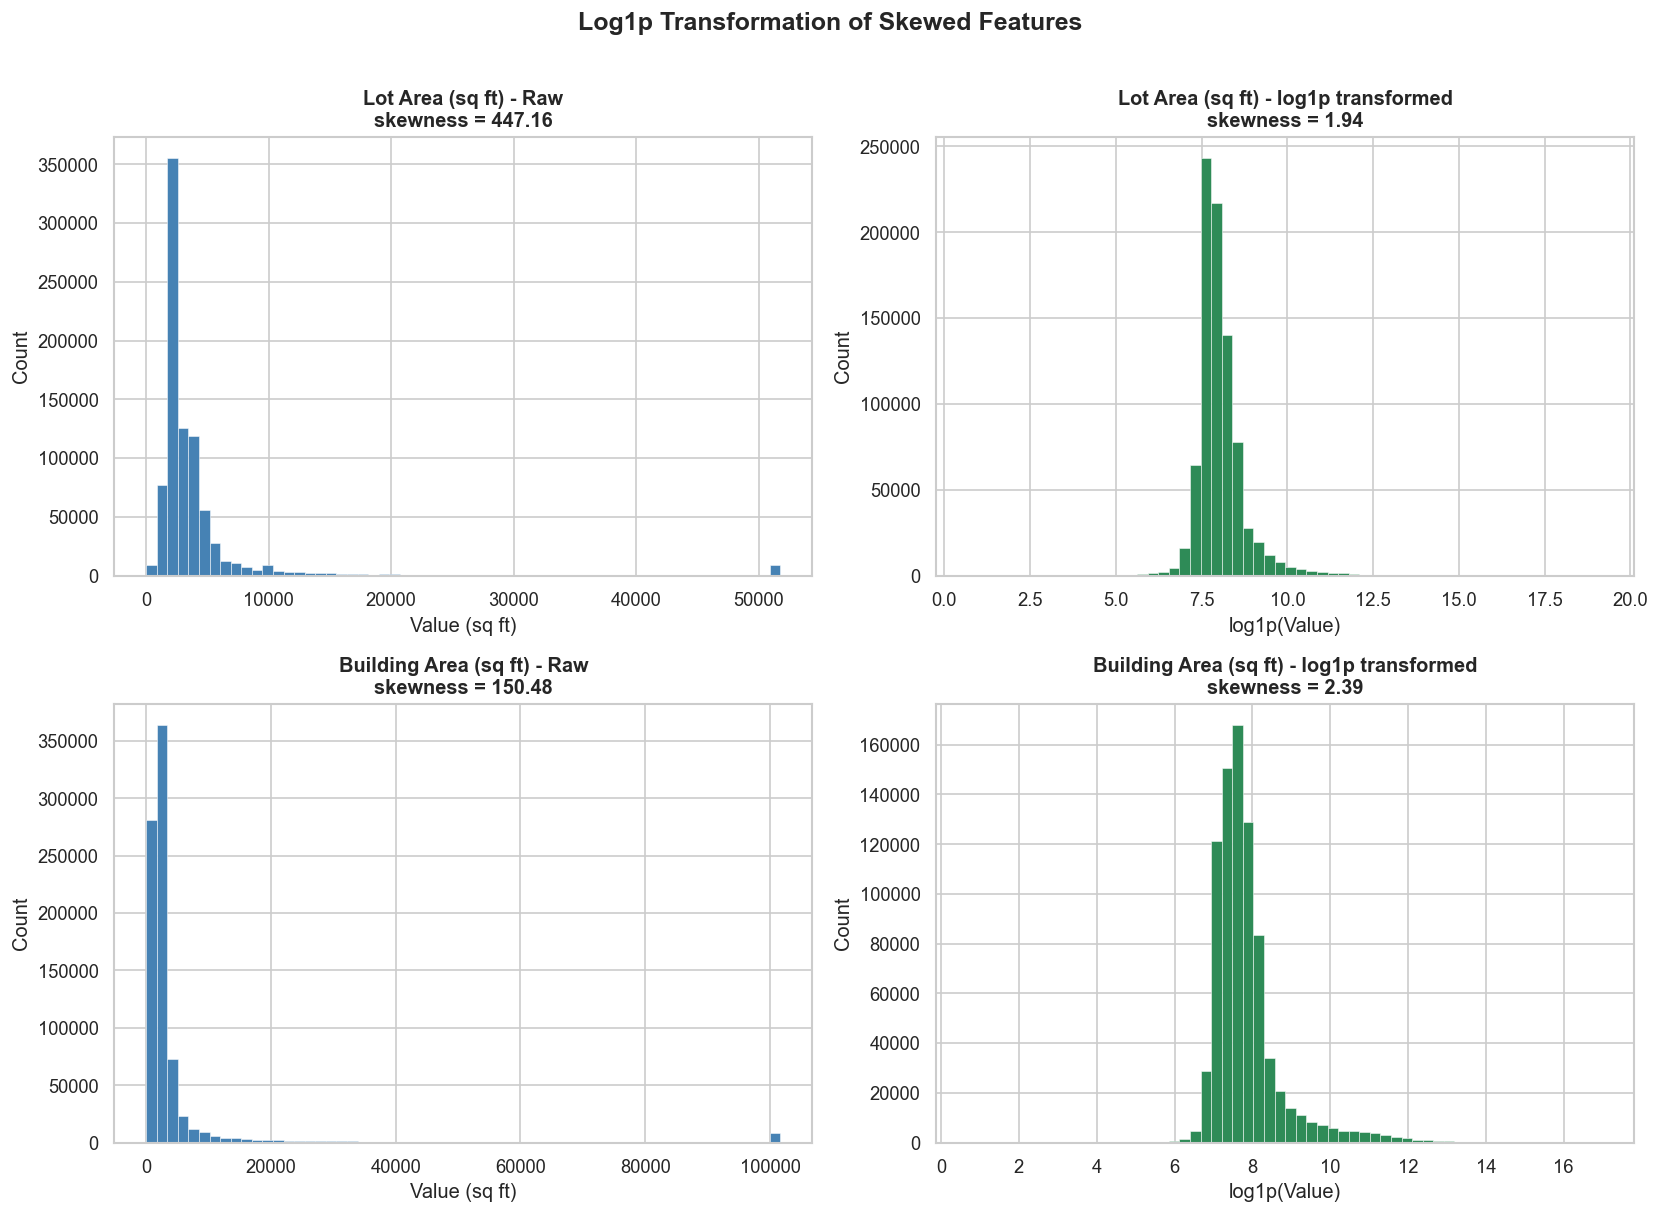

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Log1p Transformation of Skewed Features', fontsize=15, fontweight='bold', y=1.01)

features_to_log = ['lotarea', 'bldgarea']
labels = ['Lot Area (sq ft)', 'Building Area (sq ft)']

for i, (col, label) in enumerate(zip(features_to_log, labels)):
    series = df[col].dropna()
    series = series[series > 0]          # restrict to positive values
    clip_val = series.quantile(0.99)     # clip extreme outliers for display only

    skew_before = round(series.skew(), 2)
    skew_after  = round(np.log1p(series).skew(), 2)

    # Raw distribution (clipped at 99th percentile for readability)
    ax = axes[i, 0]
    ax.hist(series.clip(upper=clip_val), bins=60,
            color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{label} - Raw\nskewness = {skew_before}', fontweight='bold')
    ax.set_xlabel('Value (sq ft)')
    ax.set_ylabel('Count')

    # log1p-transformed distribution
    ax = axes[i, 1]
    ax.hist(np.log1p(series), bins=60,
            color='seagreen', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{label} - log1p transformed\nskewness = {skew_after}', fontweight='bold')
    ax.set_xlabel('log1p(Value)')
    ax.set_ylabel('Count')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '03_lotarea_bldgarea_log_transform.png')
plt.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

**Observation:** Both raw distributions are strongly right-skewed (skewness far above 1),
driven by a small number of extremely large lots and buildings. After `log1p` transformation the
distributions become approximately bell-shaped (skewness near 0), which makes Euclidean distance a
meaningful metric.

The downstream pipeline applies `log1p` to 11 right-skewed features in total:
`lotarea`, `bldgarea`, `resarea`, `comarea`, `officearea`, `retailarea`, `garagearea`, `strgearea`,
`unitstotal`, `unitsres`, and the engineered `building_density`.

## 6.3: `landuse` as an Interpretation Variable

`landuse` is a categorical feature with a small set of codes representing land use types
(e.g., `01` = One & Two Family Buildings, `05` = Commercial & Office Buildings).

One-hot encoding `landuse` as a clustering input was initially considered, then rejected. Feeding an
administrative land-use label into the clustering would cause disguised labeling: the algorithm would
reproduce the known land-use categories instead of discovering structure from the physical and
functional measurements. `landuse` is therefore **excluded from the clustering input** and retained
for blind post-clustering cross-tabulation only (Section 7 and the final notebook).

The distribution and the one-hot illustration below are shown as interpretation context and as a
record of the encoding that was considered, not as a step toward a clustering feature.

landuse value counts:
  Code              Count    Share
  ---------------------------------
  1.0             566,773    66.0%
  2.0             131,604    15.3%
  3.0              13,372     1.6%
  4.0              56,427     6.6%
  5.0              21,277     2.5%
  6.0               9,317     1.1%
  7.0               6,352     0.7%
  8.0              12,082     1.4%
  9.0               4,779     0.6%
  10.0              9,244     1.1%
  11.0             24,704     2.9%


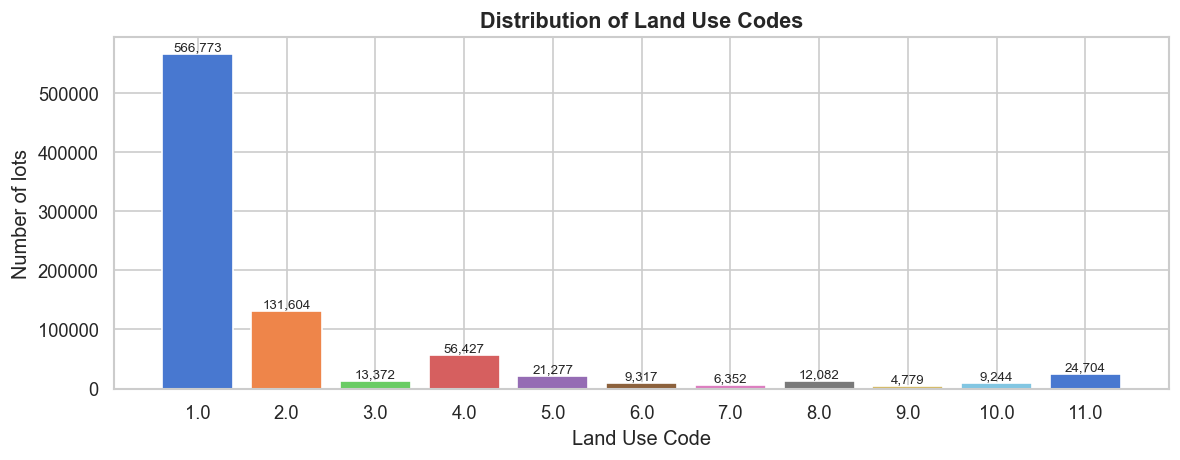

In [6]:
vc = df['landuse'].value_counts().sort_index()
total = len(df)

print('landuse value counts:')
print('  {:<12} {:>10} {:>8}'.format('Code', 'Count', 'Share'))
print('  ' + '-' * 33)
for code, count in vc.items():
    print('  {:<12} {:>10,} {:>7.1f}%'.format(str(code), count, count / total * 100))

fig, ax = plt.subplots(figsize=(10, 4))
palette = sns.color_palette('muted', len(vc))
bars = ax.bar(vc.index.astype(str), vc.values, color=palette)
ax.set_title('Distribution of Land Use Codes', fontsize=13, fontweight='bold')
ax.set_xlabel('Land Use Code')
ax.set_ylabel('Number of lots')
for bar, val in zip(bars, vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 1000,
        f'{val:,}', ha='center', va='bottom', fontsize=8
    )
plt.tight_layout()
plt.show()

In [7]:
# One-hot encoding demonstration on a small sample
sample = df[['landuse']].dropna().head(8).copy()
encoded = pd.get_dummies(sample, columns=['landuse'], prefix='landuse', dtype=int)

print('Original:')
print(sample.to_string())
print('\nAfter one-hot encoding:')
print(encoded.to_string())
print('\nColumns created:', list(encoded.columns))
print('Number of binary columns added:', len(encoded.columns))

Original:
   landuse
0      1.0
1      1.0
2      1.0
3      2.0
4      2.0
5      5.0
6      8.0
7      6.0

After one-hot encoding:
   landuse_1.0  landuse_2.0  landuse_5.0  landuse_6.0  landuse_8.0
0            1            0            0            0            0
1            1            0            0            0            0
2            1            0            0            0            0
3            0            1            0            0            0
4            0            1            0            0            0
5            0            0            1            0            0
6            0            0            0            0            1
7            0            0            0            1            0

Columns created: ['landuse_1.0', 'landuse_2.0', 'landuse_5.0', 'landuse_6.0', 'landuse_8.0']
Number of binary columns added: 5


**If `landuse` were encoded, one-hot versus label encoding:**

For completeness, had `landuse` been used as a clustering input, the correct encoding would have been
one-hot rather than label encoding:

| Approach | Principle | Verdict |
|---|---|---|
| **Label encoding** | Map each category to an integer (01 to 1, 02 to 2, ...) | **Incorrect:** implies an ordinal relationship that does not exist between land use types |
| **One-hot encoding** | One binary column per category | **Correct choice, if used:** treats each land use type as an independent, unordered dimension |

Land use codes are nominal, not ordinal: code `04` (Mixed Residential & Commercial) is not
'greater than' code `01` (One & Two Family Buildings), which is why label encoding would be wrong.

As decided in Section 6.3, `landuse` is **excluded from the clustering input** and used for
post-clustering interpretation only, so no land-use columns enter the feature matrix.

## 6.4: Standardisation

**Why StandardScaler is mandatory before clustering:**

K-Means assigns each point to the nearest centroid using Euclidean distance.
If features have very different scales:
- `lotarea` ranges from ~100 to 1,000,000+ sq ft
- `numfloors` ranges from 1 to ~100

then `lotarea` alone dominates every distance calculation and `numfloors` becomes irrelevant to
cluster assignment. The algorithm would effectively ignore the other features.

**StandardScaler** transforms each feature to mean = 0, std = 1:

    x_scaled = (x - mean) / std

Every feature then contributes equally to Euclidean distance, regardless of its original unit.

> **Note:** Final scaling is applied in the downstream pipeline
> (`notebooks/02_clustering/pca_then_clustering.ipynb`, Part 0).
> The demonstration below uses a representative sample only.

In [8]:
demo_cols = ['lotarea', 'bldgarea', 'numfloors', 'building_age']

sample_raw = df[demo_cols].dropna().head(2000).copy()

scaler = StandardScaler()
scaled_values = scaler.fit_transform(sample_raw)
sample_scaled = pd.DataFrame(
    scaled_values,
    columns=[c + '_scaled' for c in demo_cols]
)

print('BEFORE StandardScaler (first 2,000 rows):')
print(sample_raw.describe().round(2))

print('\nAFTER StandardScaler (first 2,000 rows):')
print(sample_scaled.describe().round(4))

BEFORE StandardScaler (first 2,000 rows):
         lotarea   bldgarea  numfloors  building_age
count    2000.00    2000.00    2000.00       2000.00
mean     4604.50    6403.25       5.16         89.33
std     16861.83   24242.68       7.37         26.59
min       366.00       0.00       1.00          1.00
25%      1953.75    1685.75       2.00         76.00
50%      2563.50    2432.00       2.00        101.00
75%      4000.00    3212.00       3.00        106.00
max    593357.00  500000.00      45.00        175.00

AFTER StandardScaler (first 2,000 rows):
       lotarea_scaled  bldgarea_scaled  numfloors_scaled  building_age_scaled
count       2000.0000        2000.0000         2000.0000            2000.0000
mean           0.0000           0.0000           -0.0000               0.0000
std            1.0003           1.0003            1.0003               1.0003
min           -0.2514          -0.2642           -0.5643              -3.3233
25%           -0.1572          -0.1946           

**Observation:** After scaling, every feature has mean = 0 and std = 1, regardless of its
original range. K-Means will now compute distances in a balanced feature space where each
variable contributes proportionally to the final cluster assignment.

StandardScaler is applied **after** `log1p` transformation - the two operations are
complementary: `log1p` corrects distributional skewness, StandardScaler corrects scale.

---
# Section 7: Unbalanced Data

`borough` and `landuse` are both excluded from the clustering input and kept for interpretation.
Their imbalance does not bias cluster formation, but it is important context: when discovered
clusters are mapped back to boroughs and cross-tabulated against land-use codes, the uneven
representation of the categories must be kept in mind. We analyse the two dimensions below.

## 7.1: Borough Distribution

`borough` identifies which of the five NYC boroughs a lot belongs to.
It is **excluded** from K-Means input and reserved for post-clustering analysis.
We analyse it here to understand geographic representation in the dataset.

Figure saved to reports/figures/03_borough_distribution.png


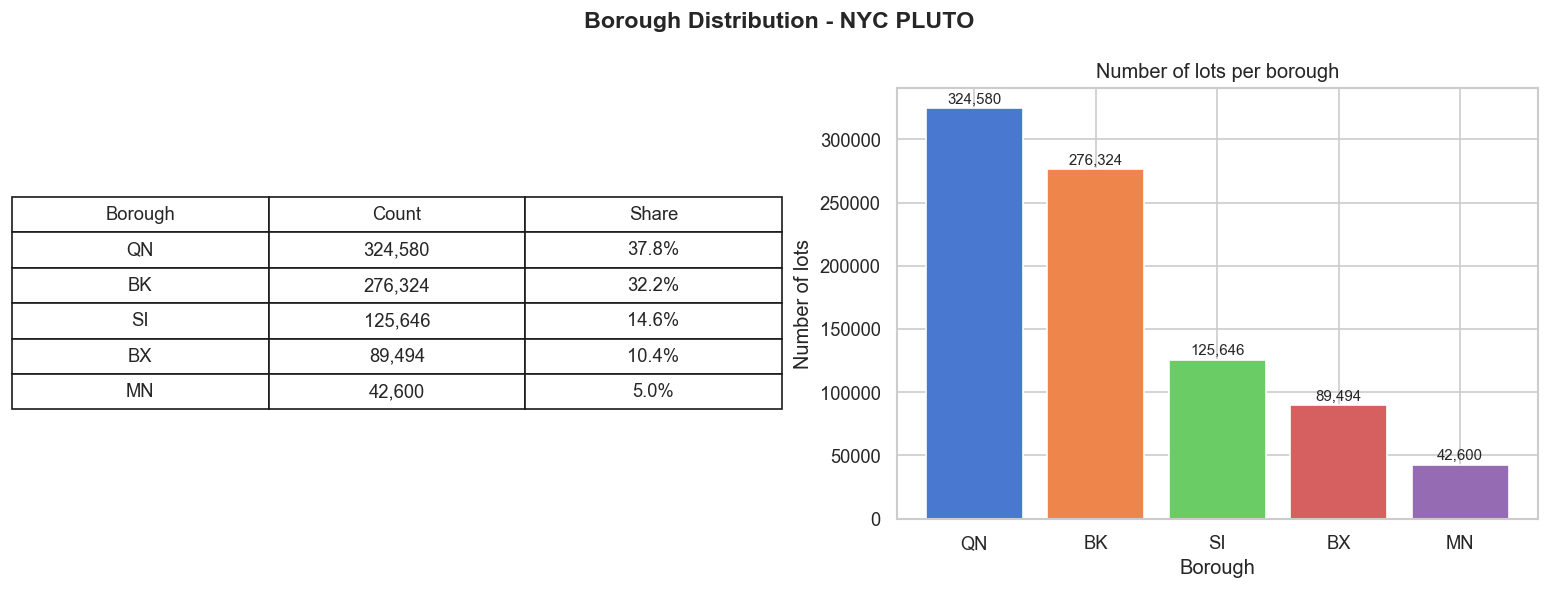

In [9]:
borough_counts = df['borough'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Borough Distribution - NYC PLUTO', fontsize=14, fontweight='bold')

# Left: summary table
axes[0].axis('off')
tbl_data = [
    [b, '{:,}'.format(n), '{:.1f}%'.format(n / len(df) * 100)]
    for b, n in borough_counts.items()
]
tbl = axes[0].table(
    cellText=tbl_data,
    colLabels=['Borough', 'Count', 'Share'],
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.9)

# Right: bar chart
palette = sns.color_palette('muted', len(borough_counts))
bars = axes[1].bar(borough_counts.index, borough_counts.values, color=palette)
axes[1].set_title('Number of lots per borough')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Number of lots')
for bar, val in zip(bars, borough_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, val + 1500,
        '{:,}'.format(val), ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '03_borough_distribution.png')
plt.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

**Observation:** The dataset is geographically imbalanced: Brooklyn and Queens together represent the
majority of lots, while Staten Island is the least represented borough.

**Impact on our model:**  
Because `borough` is excluded from the clustering input, this imbalance does not directly bias cluster
formation. It is important context for the geographic analysis in the final notebook: when clusters
are mapped back to geography, some clusters may over-represent dense boroughs simply because those
boroughs contribute more observations.

## 7.2: Land Use Distribution

`landuse` is **excluded from the clustering input** and used for post-clustering interpretation only.
Its distribution is examined here as context: the strong imbalance across land-use codes explains the
relative sizes of the typologies found downstream and frames the blind cross-tabulation between
discovered clusters and official land-use codes in the final notebook.

Figure saved to reports/figures/03_landuse_distribution.png


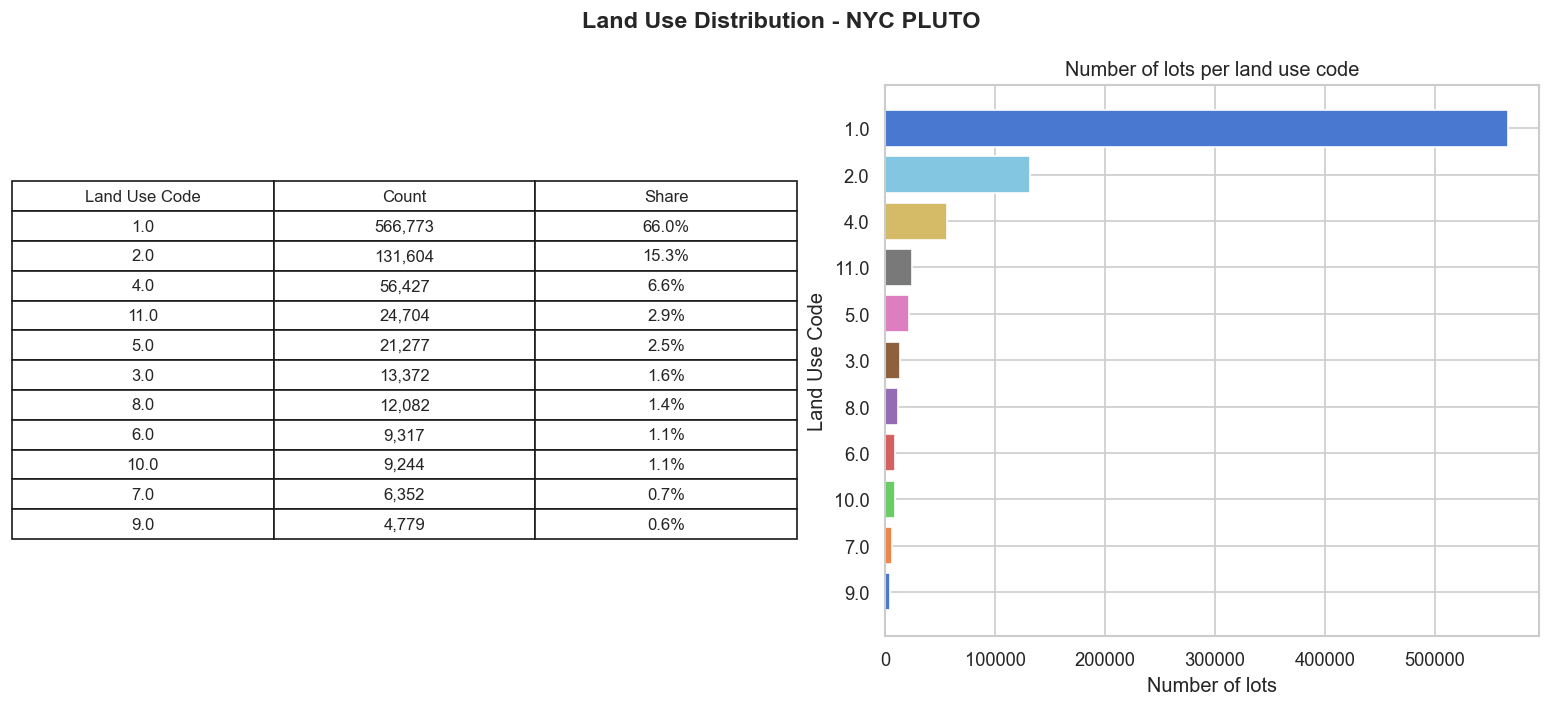

In [10]:
lu_counts = df['landuse'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Land Use Distribution - NYC PLUTO', fontsize=14, fontweight='bold')

# Left: summary table (sorted descending)
axes[0].axis('off')
tbl_data = [
    [str(lu), '{:,}'.format(n), '{:.1f}%'.format(n / len(df) * 100)]
    for lu, n in lu_counts.items()
]
tbl = axes[0].table(
    cellText=tbl_data,
    colLabels=['Land Use Code', 'Count', 'Share'],
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)

# Right: horizontal bar chart (sorted ascending for readability)
lu_sorted = lu_counts.sort_values(ascending=True)
palette = sns.color_palette('muted', len(lu_sorted))
axes[1].barh(lu_sorted.index.astype(str), lu_sorted.values, color=palette)
axes[1].set_title('Number of lots per land use code')
axes[1].set_xlabel('Number of lots')
axes[1].set_ylabel('Land Use Code')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '03_landuse_distribution.png')
plt.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

**Observation:** The `landuse` distribution is strongly unbalanced. Residential codes (typically
codes 01 and 02) account for the large majority of NYC lots, while commercial, industrial, and
mixed-use types are substantially under-represented.

**How this is used:** Because `landuse` is excluded from the clustering input, this imbalance does not
bias cluster formation. It is relevant for interpretation: the dominant residential share is context
for the size of the residential clusters found downstream, and it is the baseline against which the
blind cluster-versus-landuse cross-tabulation is read. Resampling (SMOTE, undersampling) is not
applied, because the imbalance reflects real NYC urban composition, not a data collection artefact.

---
# Section 8: Final Synthesis and Preprocessing Recommendations

This section consolidates the findings from all three EDA notebooks and defines the complete
feature set and the preprocessing pipeline that is implemented downstream in the clustering notebook
(`notebooks/02_clustering/pca_then_clustering.ipynb`, Part 0).

## 8.1: Key EDA Findings

### From Notebook 1: Dataset Discovery

- Dataset confirmed: 858,644 rows, 101 columns. One row = one land lot or building in NYC.
- 20 columns explored from the 101 available, grouped into Physical (6), Functional (8), and categorical/geographic attributes (6). Only the numeric physical and functional measurements feed the clustering; `landuse`, `borough`, `postcode`, `community board`, `latitude`, `longitude`, and `assesstot` are reserved for interpretation.
- Missing values are mostly under 5% for the selected features.
- Special encoded missing values (-999, NULL, NA, N/A) were checked and do not appear in the selected features.
- The full dataset contains several columns with >50% missing values, which is why feature selection was restricted.

### From Notebook 2: Visualizations and Outliers

- Extreme right-skewness confirmed on area-based features (`lotarea`, `bldgarea`, `comarea` show very high skewness); log1p transformation is required before clustering.
- Outliers detected by the IQR method on several features (`lotarea`, `bldgarea`, `unitstotal`, `numfloors` after the cap at 104 floors, `yearbuilt`, `resarea`); these are winsorized rather than dropped.
- Impossible values identified: `yearbuilt == 0` and `bldgarea == 0` (each in a small share of rows), plus `numfloors > 104` and `numfloors > 4` for one-and-two-family lots. These are set to NaN before clustering.
- High redundancy detected via Pearson correlation (`unitsres` vs `resarea`, `unitsres` vs `unitstotal`, both above 0.80). This redundancy is addressed downstream by PCA; correlated features are retained, not dropped manually.
- Scale differences are large, confirming the need for StandardScaler.

### From Notebook 3: Feature Engineering

- 4 new features created: `building_age`, `building_density`, `residential_ratio` (clustering inputs) and `value_per_sqft` (interpretation only).
- `log1p` validated as essential for the right-skewed area and count features.
- `landuse` is excluded from the clustering input (encoding it would reproduce known categories); it is kept for blind post-clustering cross-tabulation.
- StandardScaler is necessary to equalise feature scales before clustering.
- Borough imbalance does not bias clustering (`borough` excluded from the input).
- Land-use imbalance is acknowledged as interpretation context.

## 8.2: Final Feature Selection

### Clustering Input (13 source features + 3 engineered = 16 features)

`landuse` is **not** a clustering input. `yearbuilt` is not a clustering feature either: it is
winsorized and then converted into `building_age`.

| # | Feature | Type | Preprocessing |
|---|---|---|---|
| 1 | `lotarea` | Numerical | log1p + StandardScaler |
| 2 | `bldgarea` | Numerical | log1p + StandardScaler |
| 3 | `numfloors` | Numerical | StandardScaler |
| 4 | `lotfront` | Numerical | StandardScaler |
| 5 | `lotdepth` | Numerical | StandardScaler |
| 6 | `unitstotal` | Numerical | log1p + StandardScaler |
| 7 | `unitsres` | Numerical | log1p + StandardScaler |
| 8 | `resarea` | Numerical | log1p + StandardScaler |
| 9 | `comarea` | Numerical | log1p + StandardScaler |
| 10 | `officearea` | Numerical | log1p + StandardScaler |
| 11 | `retailarea` | Numerical | log1p + StandardScaler |
| 12 | `garagearea` | Numerical | log1p + StandardScaler |
| 13 | `strgearea` | Numerical | log1p + StandardScaler |
| 14 | `building_age` | Numerical (engineered) | StandardScaler |
| 15 | `building_density` | Numerical (engineered) | log1p + StandardScaler |
| 16 | `residential_ratio` | Numerical (engineered) | StandardScaler |

`log1p` is applied to 11 of the 16 features (the area and count features plus `building_density`);
the other 5 (`numfloors`, `lotfront`, `lotdepth`, `building_age`, `residential_ratio`) are scaled
without a log transform.

### Post-Clustering Interpretation Only

| Feature | Purpose |
|---|---|
| `landuse` | Blind post-clustering cross-tabulation of clusters against land-use codes |
| `borough` | Geographic distribution of clusters across the 5 boroughs |
| `postcode` | Neighbourhood-level cluster mapping |
| `community board` | Community district analysis |
| `latitude`, `longitude` | Spatial visualisation of clusters on a map |
| `assesstot` | Raw property value profile per cluster |
| `value_per_sqft` | Normalised property value per cluster (engineered) |

## 8.3: Preprocessing Pipeline (implemented downstream)

The preprocessing pipeline is implemented in `notebooks/02_clustering/pca_then_clustering.ipynb`
(Part 0), where preprocessing, PCA, and clustering are consolidated into a single notebook. For
reproducibility, that pipeline rebuilds the feature matrix directly from the raw file
(`data/raw/pluto_working_copy.csv`) and does not read any EDA output. The steps are applied in this
order:

**Step 1: Numeric parsing**  
Strip the narrow no-break space (U+202F) thousands separator from the numeric columns and coerce them
to float.

**Step 2: Impossible values to NaN**  
`yearbuilt == 0` set to NaN, `bldgarea == 0` set to NaN, `numfloors > 104` set to NaN, and
`numfloors > 4` set to NaN for one-and-two-family lots (`landuse` code 1).

**Step 3: IQR winsorization (1.5 x IQR)**  
Cap the seven heavy-tailed features: `lotfront`, `lotdepth`, `lotarea`, `bldgarea`, `unitstotal`,
`resarea`, and `yearbuilt`. Capping is preferred over deletion to preserve dataset size.

**Step 4: Engineered features**  
`building_age = 2026 - yearbuilt`, `building_density = bldgarea / lotarea`, and
`residential_ratio = unitsres / unitstotal` (clipped to [0, 1]).

**Step 5: Drop rows with any missing clustering feature**  
Rows that still have at least one NaN across the 16 clustering features are dropped. `landuse` is
not a clustering input and is not one-hot encoded; it is retained only for post-clustering
interpretation. This drop is the primary source of the reduction from 858,644 raw rows to 682,515
clustering rows.

**Step 6: log1p transformation**  
Apply `log1p` to the 11 right-skewed features: `lotarea`, `bldgarea`, `unitstotal`, `unitsres`,
`resarea`, `comarea`, `officearea`, `retailarea`, `garagearea`, `strgearea`, and `building_density`.

**Step 7: StandardScaler**  
Standardize all 16 features to mean 0 and standard deviation 1, fitted on the full cleaned dataset.

**Outputs:** `data/processed/X_scaled.csv` (the scaled feature matrix), together with
`X_scaled_features.csv`, `pluto_companion.csv`, and `sample_index.csv`.

In [11]:
# Save the dataframe with all engineered features as an EDA deliverable.
# NOTE: pluto_engineered.csv is an EDA artifact only. The downstream clustering pipeline
# (notebooks/02_clustering/pca_then_clustering.ipynb, Part 0) rebuilds the feature matrix
# directly from the raw file and does NOT read this file.
output_path = 'data/processed/pluto_engineered.csv'
df.to_csv(output_path, index=False)

print(f'Engineered dataframe saved to: {output_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns added in this notebook: {new_features}')
print('Note: this file is an EDA deliverable; the clustering pipeline rebuilds the matrix from the raw file.')

Engineered dataframe saved to: data/processed/pluto_engineered.csv
Shape: 858,644 rows x 105 columns
Columns added in this notebook: ['building_age', 'building_density', 'residential_ratio', 'value_per_sqft']
Note: this file is an EDA deliverable; the clustering pipeline rebuilds the matrix from the raw file.


## 8.4: Next Steps

Preprocessing, PCA, and clustering are consolidated in
`notebooks/02_clustering/pca_then_clustering.ipynb`, which rebuilds the feature matrix from the raw
file, applies the pipeline above, runs PCA, and compares K-Means, DBSCAN, and Ward hierarchical
clustering. The mini-project notebook (`notebooks/03_mini_project/mini_project.ipynb`) explores PCA
and visualization, and the final notebook (`notebooks/04_final/final_project.ipynb`) presents the
consolidated analysis.

The research question is answered downstream: each cluster is characterised by its dominant physical
and functional traits, and the discovered typologies are mapped across the five boroughs.